# Car Price Prediction Using Machine Learning
Building an optimized regression system workflow designed to predict valuation price parameters of consumer vehicles from contextual operational factors.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

sns.set_style('darkgrid')

## 1. Context Exploration & Ingestion

In [5]:
car_df = pd.read_csv('car_data.csv')
print(car_df.shape)
car_df.head()

(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
# Engineering a relative numeric metrics column to track item age depreciation profiles
car_df['Car_Age'] = 2026 - car_df['Year']
car_df = car_df.drop(columns=['Year', 'Car_Name'])

car_df.describe(include='all')

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
count,301.000000,301.000000,301.000000,301,301,301,301.000000,301.000000
unique,NaN,NaN,NaN,3,2,2,NaN,NaN
top,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN,NaN
freq,NaN,NaN,NaN,239,195,261,NaN,NaN
mean,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189,12.372093
std,5.082812,8.642584,38886.883882,NaN,NaN,NaN,0.247915,2.891554
min,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000,8.000000
25%,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000,10.000000
50%,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000,12.000000
75%,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000,14.000000


## 2. Correlation & Feature Analytics

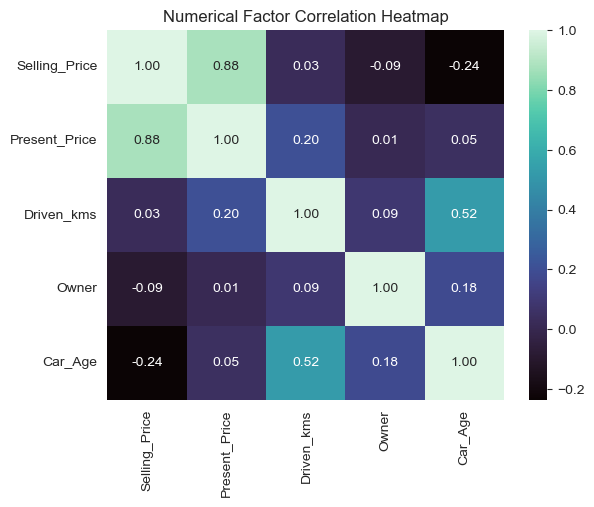

In [10]:
# Heatmap displaying mutual geometric properties among quantitative parameters
numeric_cols = car_df.select_dtypes(include=[np.number]).columns
sns.heatmap(car_df[numeric_cols].corr(), annot=True, cmap='mako', fmt='.2f')
plt.title('Numerical Factor Correlation Heatmap')
plt.show()

## 3. Modeling Workflow Design

In [11]:
X = car_df.drop(columns=['Selling_Price'])
y = car_df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define separate structural lists mapping spatial tracking column roles
categorical_features = ['Fuel_Type', 'Selling_type', 'Transmission']
numerical_features = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']

# Structured transformation pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Combine preprocessing and ensemble model inside an organized Pipeline structure
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Model pipeline trained successfully!")

Model pipeline trained successfully!


## 4. Evaluation Profiles

In [12]:
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

R-squared (Variance Explained): 0.9617
Mean Absolute Error: 0.5871
Root Mean Squared Error: 0.9398


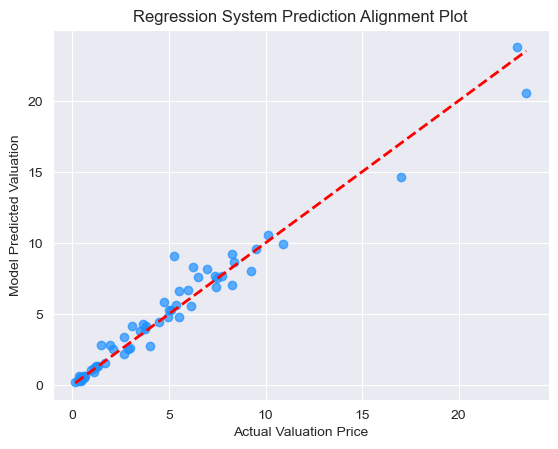

In [13]:
# Graphical scatter plot validation matching raw observations with regression predictions
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Valuation Price')
plt.ylabel('Model Predicted Valuation')
plt.title('Regression System Prediction Alignment Plot')
plt.show()